# ---------- Data loading notebook ----------

The goal of this notebook is to load and combine London bike-sharing trip data from 2024 and 2025.

Author: Artur Werys

In [27]:
from pathlib import Path
import pandas as pd
import xml.etree.ElementTree as et

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [2]:
BASE_DIR = Path(".")
DATA_DIR = BASE_DIR / "Data"

DATA_2024_DIR = DATA_DIR / "2024"
DATA_2025_DIR = DATA_DIR / "2025"

STATIONS_FILE = DATA_DIR / "stations.xml"

## ---------- Loading CSV data function ----------


In [3]:
def load_data(folder_path):
    files = list(folder_path.glob("*.csv"))
    dataframes = []

    for file in files:
        df = pd.read_csv(file)
        dataframes.append(df)

    combined_data = pd.concat(dataframes, ignore_index=True)

    return combined_data

## ---------- Loading data from choosen years ----------


In [4]:
print("--- Loading data from 2025... ---")

data_2025 = load_data(DATA_2025_DIR)

print(data_2025.head())
print("Number of trips in 2025:", len(data_2025))


print("--- Loading data from 2024... ---")

data_2024 = load_data(DATA_2024_DIR)

print(data_2024.head())
print("Number of trips in 2024:", len(data_2024))

--- Loading data from 2025... ---
      Number        Start date  Start station number  \
0  145666816  2025-01-14 23:59                  1043   
1  145666817  2025-01-14 23:59                300015   
2  145666818  2025-01-14 23:59                  1068   
3  145666819  2025-01-14 23:59                  1159   
4  145666812  2025-01-14 23:58                200048   

                      Start station          End date  End station number  \
0        Museum of London, Barbican  2025-01-15 00:13            200149.0   
1          Binfield Road, Stockwell  2025-01-15 00:04            300229.0   
2  Norton Folgate, Liverpool Street  2025-01-15 00:10              1051.0   
3         Berry Street, Clerkenwell  2025-01-15 00:10              1007.0   
4          Page Street, Westminster  2025-01-15 00:14              1058.0   

                        End station  Bike number  Bike model Total duration  \
0           Watney Street, Shadwell        55223     CLASSIC        14m 30s   
1       

### ---------- Combining datasets ----------


In [5]:
combined_trip_data = pd.concat(
    [data_2024, data_2025],
    ignore_index=True
)

### ---------- Renaming columns ----------


In [6]:
combined_trip_data = combined_trip_data.rename(columns={
    "Number": "trip_id",
    "Start date": "start_date",
    "End date": "end_date",
    "Start station number": "start_station_id",
    "Start station": "start_station_name",
    "End station number": "end_station_id",
    "End station": "end_station_name",
    "Bike number": "bike_id",
    "Bike model": "bike_model",
    "Total duration": "total_duration",
    "Total duration (ms)": "total_duration_ms",
})

combined_trip_data.head()

,trip_id,start_date,start_station_id,start_station_name,end_date,end_station_id,end_station_name,bike_id,bike_model,total_duration,total_duration_ms
0,136666627,2024-01-14 23:59,1108,"North Wharf Road, Paddington",2024-01-15 00:06,3423.0,"Maida Vale, Maida Vale",53020.0,CLASSIC,6m 47s,407799.0
1,136666625,2024-01-14 23:57,3447,"Gloucester Road (North), Kensington",2024-01-15 00:05,1214.0,"Kensington Olympia Station, Olympia",54559.0,CLASSIC,8m 1s,481276.0
2,136666626,2024-01-14 23:57,1090,"Warren Street Station, Euston",2024-01-15 00:02,200005.0,"New Cavendish Street, Marylebone",52133.0,CLASSIC,5m 11s,311788.0
3,136666622,2024-01-14 23:56,200058,"Northdown Street, King's Cross",2024-01-15 00:06,2687.0,"Brick Lane Market, Shoreditch",60341.0,PBSC_EBIKE,10m 14s,614030.0
4,136666623,2024-01-14 23:56,1052,"Soho Square , Soho",2024-01-15 00:23,1150.0,"Queensway, Kensington Gardens",55212.0,CLASSIC,27m 1s,1621583.0


### ---------- Checking for missing values in combined data ----------


In [7]:
print("Missing values in each column:")
print(combined_trip_data.isna().sum())

len_before_dropping = len(combined_trip_data)

print("Dropping rows with missing data...")

combined_trip_data = combined_trip_data.dropna(
    subset=["end_date", "end_station_id", "bike_id"]
)

len_after_dropping = len(combined_trip_data)

dropped_rows_count = len_before_dropping - len_after_dropping

print("Missing values in each column after dropping rows with missing data:")
print(combined_trip_data.isna().sum())

print(f"Number of dropped rows: {dropped_rows_count}")

Missing values in each column:
trip_id                 0
start_date              0
start_station_id        0
start_station_name      0
end_date              184
end_station_id        184
end_station_name      184
bike_id                 1
bike_model              0
total_duration        184
total_duration_ms     184
dtype: int64
Dropping rows with missing data...
Missing values in each column after dropping rows with missing data:
trip_id               0
start_date            0
start_station_id      0
start_station_name    0
end_date              0
end_station_id        0
end_station_name      0
bike_id               0
bike_model            0
total_duration        0
total_duration_ms     0
dtype: int64
Number of dropped rows: 185


## ---------- Loading station data from XML ----------


In [8]:
tree = et.parse(STATIONS_FILE)
root = tree.getroot()

stations_data = []

for station in root.findall("station"):

    station_data = [
        station.find("name").text.strip(),
        station.find("lat").text,
        station.find("long").text
    ]

    stations_data.append(station_data)

stations_df = pd.DataFrame(
    stations_data,
    columns=[
        "station_name",
        "latitude",
        "longitude"
    ]
)

print("--- Station data loaded from XML ---")
print(stations_df.head())
print("Number of stations:", len(stations_df))

--- Station data loaded from XML ---
                           station_name     latitude     longitude
0            River Street , Clerkenwell  51.52916347  -0.109970527
1        Phillimore Gardens, Kensington  51.49960695  -0.197574246
2  Christopher Street, Liverpool Street  51.52128377  -0.084605692
3       St. Chad's Street, King's Cross  51.53005939  -0.120973687
4         Sedding Street, Sloane Square     51.49313     -0.156876
Number of stations: 801


### ---------- Merging stations from trip data with geograpical data ----------


In [9]:
combined_trip_data = pd.merge(combined_trip_data, stations_df, left_on="start_station_name", right_on="station_name", how ="left")
combined_trip_data = combined_trip_data.rename(columns={
    "latitude": "start_lat",
    "longitude": "start_lon"
})

combined_trip_data = combined_trip_data.drop(columns=["station_name"])
combined_trip_data.head()

combined_trip_data = pd.merge(combined_trip_data, stations_df, left_on="end_station_name", right_on="station_name", how ="left")
combined_trip_data = combined_trip_data.rename(columns={
    "latitude": "end_lat",
    "longitude": "end_lon"
})

combined_trip_data = combined_trip_data.drop(columns=["station_name"])
combined_trip_data.head()

,trip_id,start_date,start_station_id,start_station_name,end_date,end_station_id,end_station_name,bike_id,bike_model,total_duration,total_duration_ms,start_lat,start_lon,end_lat,end_lon
0,136666627,2024-01-14 23:59,1108,"North Wharf Road, Paddington",2024-01-15 00:06,3423.0,"Maida Vale, Maida Vale",53020.0,CLASSIC,6m 47s,407799.0,51.518623,-0.17660300000000007,51.529857,-0.18348604
1,136666625,2024-01-14 23:57,3447,"Gloucester Road (North), Kensington",2024-01-15 00:05,1214.0,"Kensington Olympia Station, Olympia",54559.0,CLASSIC,8m 1s,481276.0,51.49792478,-0.183834706,51.49815779,-0.209494128
2,136666626,2024-01-14 23:57,1090,"Warren Street Station, Euston",2024-01-15 00:02,200005.0,"New Cavendish Street, Marylebone",52133.0,CLASSIC,5m 11s,311788.0,51.52443845,-0.138019439,51.519167,-0.147983
3,136666622,2024-01-14 23:56,200058,"Northdown Street, King's Cross",2024-01-15 00:06,2687.0,"Brick Lane Market, Shoreditch",60341.0,PBSC_EBIKE,10m 14s,614030.0,51.531066,-0.11934,51.52261762,-0.071653961
4,136666623,2024-01-14 23:56,1052,"Soho Square , Soho",2024-01-15 00:23,1150.0,"Queensway, Kensington Gardens",55212.0,CLASSIC,27m 1s,1621583.0,51.51563144,-0.132328837,51.51031,-0.18740235


### ---------- Deleting trips without geographical data ----------


In [10]:
final_trip_data = combined_trip_data.dropna(subset=["start_lat", "start_lon", "end_lat", "end_lon"])

# How many trips were deleted?
print(f"Percentage of trips deleted: {((len(combined_trip_data) - len(final_trip_data)) / len(combined_trip_data) * 100):.2f}%")


Percentage of trips deleted: 2.23%


## ---------- Saving final trip data as parquet ----------


In [11]:
final_trip_data["start_date"] = pd.to_datetime(
    final_trip_data["start_date"],
    format="mixed",
    dayfirst=True
)

final_trip_data["end_date"] = pd.to_datetime(
    final_trip_data["end_date"],
    format="mixed",
    dayfirst=True
)

final_trip_data.to_parquet(DATA_DIR / "final_trip_data.parquet")

In [12]:
final_trip_data.head()

,trip_id,start_date,start_station_id,start_station_name,end_date,end_station_id,end_station_name,bike_id,bike_model,total_duration,total_duration_ms,start_lat,start_lon,end_lat,end_lon
0,136666627,2024-01-14 23:59:00,1108,"North Wharf Road, Paddington",2024-01-15 00:06:00,3423.0,"Maida Vale, Maida Vale",53020.0,CLASSIC,6m 47s,407799.0,51.518623,-0.17660300000000007,51.529857,-0.18348604
1,136666625,2024-01-14 23:57:00,3447,"Gloucester Road (North), Kensington",2024-01-15 00:05:00,1214.0,"Kensington Olympia Station, Olympia",54559.0,CLASSIC,8m 1s,481276.0,51.49792478,-0.183834706,51.49815779,-0.209494128
2,136666626,2024-01-14 23:57:00,1090,"Warren Street Station, Euston",2024-01-15 00:02:00,200005.0,"New Cavendish Street, Marylebone",52133.0,CLASSIC,5m 11s,311788.0,51.52443845,-0.138019439,51.519167,-0.147983
3,136666622,2024-01-14 23:56:00,200058,"Northdown Street, King's Cross",2024-01-15 00:06:00,2687.0,"Brick Lane Market, Shoreditch",60341.0,PBSC_EBIKE,10m 14s,614030.0,51.531066,-0.11934,51.52261762,-0.071653961
4,136666623,2024-01-14 23:56:00,1052,"Soho Square , Soho",2024-01-15 00:23:00,1150.0,"Queensway, Kensington Gardens",55212.0,CLASSIC,27m 1s,1621583.0,51.51563144,-0.132328837,51.51031,-0.18740235


In [13]:
final_trip_data.head(-5)

,trip_id,start_date,start_station_id,start_station_name,end_date,end_station_id,end_station_name,bike_id,bike_model,total_duration,total_duration_ms,start_lat,start_lon,end_lat,end_lon
0,136666627,2024-01-14 23:59:00,1108,"North Wharf Road, Paddington",2024-01-15 00:06:00,3423.0,"Maida Vale, Maida Vale",53020.0,CLASSIC,6m 47s,407799.0,51.518623,-0.17660300000000007,51.529857,-0.18348604
1,136666625,2024-01-14 23:57:00,3447,"Gloucester Road (North), Kensington",2024-01-15 00:05:00,1214.0,"Kensington Olympia Station, Olympia",54559.0,CLASSIC,8m 1s,481276.0,51.49792478,-0.183834706,51.49815779,-0.209494128
2,136666626,2024-01-14 23:57:00,1090,"Warren Street Station, Euston",2024-01-15 00:02:00,200005.0,"New Cavendish Street, Marylebone",52133.0,CLASSIC,5m 11s,311788.0,51.52443845,-0.138019439,51.519167,-0.147983
3,136666622,2024-01-14 23:56:00,200058,"Northdown Street, King's Cross",2024-01-15 00:06:00,2687.0,"Brick Lane Market, Shoreditch",60341.0,PBSC_EBIKE,10m 14s,614030.0,51.531066,-0.11934,51.52261762,-0.071653961
4,136666623,2024-01-14 23:56:00,1052,"Soho Square , Soho",2024-01-15 00:23:00,1150.0,"Queensway, Kensington Gardens",55212.0,CLASSIC,27m 1s,1621583.0,51.51563144,-0.132328837,51.51031,-0.18740235
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17823198,154538231,2025-12-16 00:02:00,2677,"Natural History Museum, South Kensington",2025-12-16 00:07:00,3461.0,"Sloane Avenue, Knightsbridge",52886.0,CLASSIC,5m 39s,339848.0,51.49559291,-0.179077626,51.4931848,-0.167894973
17823199,154538232,2025-12-16 00:02:00,200251,"Bow Road Station, Bow",2025-12-16 00:04:00,200174.0,"Mostyn Grove, Bow",21734.0,CLASSIC,2m 37s,157096.0,51.527058,-0.025296,51.530535,-0.025492
17823200,154538233,2025-12-16 00:02:00,1096,"Bayswater Road, Hyde Park",2025-12-16 00:06:00,200086.0,"Ilchester Gardens, Bayswater",23063.0,CLASSIC,4m 25s,265354.0,51.511933,-0.174411,51.51244,-0.19096
17823201,154538235,2025-12-16 00:02:00,200148,"Ansell House, Stepney",2025-12-16 00:48:00,1077.0,"Royal London Hospital, Whitechapel",53261.0,CLASSIC,46m 3s,2763361.0,51.520019,-0.05438,51.518675,-0.06111


In [20]:
station_name = "Waterloo Station 3, Waterloo"

departures = final_trip_data.loc[
    final_trip_data["start_station_name"] == station_name,
    ["start_date"]
].copy()

departures = departures.rename(columns={"start_date": "date"})
departures["change"] = -1


arrivals = final_trip_data.loc[
    final_trip_data["end_station_name"] == station_name,
    ["end_date"]
].copy()

arrivals = arrivals.rename(columns={"end_date": "date"})
arrivals["change"] = 1


station_events = pd.concat([departures, arrivals])
station_events = station_events.sort_values("date")


station_events = station_events[
    (station_events["date"] >= "2024-01-01") &
    (station_events["date"] < "2026-01-01")
].copy()

station_events = station_events.sort_values("date")

station_events["balance"] = station_events["change"].cumsum()
station_events["balance"] = station_events["balance"].shift(fill_value=0)

station_events.head()

,date,change,balance
209564,2024-01-01 08:02:00,1,0
209362,2024-01-01 09:18:00,1,1
209293,2024-01-01 09:39:00,1,2
209297,2024-01-01 09:39:00,1,3
209388,2024-01-01 10:43:00,1,4


In [21]:
station_events = station_events[
    (station_events["date"] >= "2024-01-01") &
    (station_events["date"] < "2026-01-01")
].copy()

station_events = station_events.sort_values("date")

station_events["balance"] = station_events["change"].cumsum()
station_events["balance"] = station_events["balance"].shift(fill_value=0)

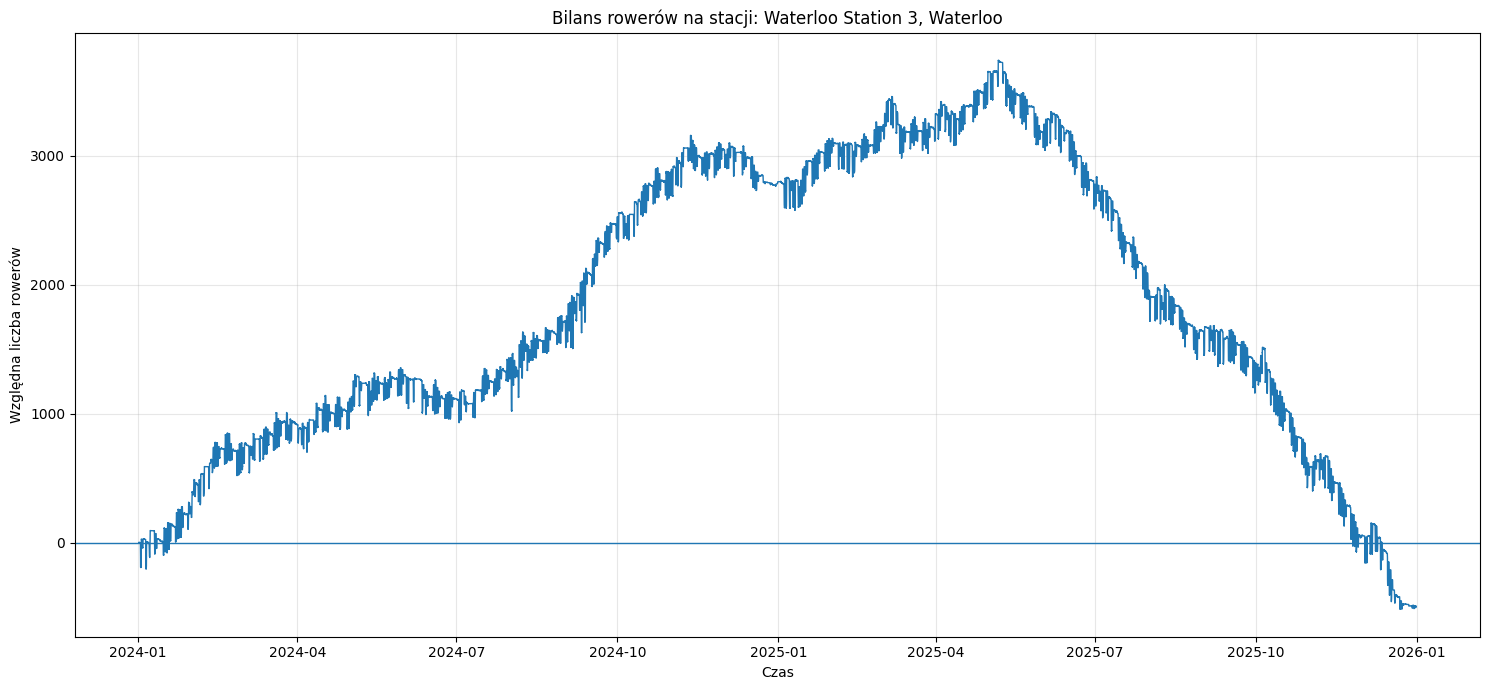

In [22]:
plt.figure(figsize=(15, 7))

plt.plot(station_events["date"], station_events["balance"], linewidth=1)

plt.axhline(0, linewidth=1)

plt.xlabel("Czas")
plt.ylabel("Względna liczba rowerów")
plt.title(f"Bilans rowerów na stacji: {station_name}")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [23]:
selected_day = "2025-05-15"

one_day_events = station_events[
    station_events["date"].dt.date == pd.to_datetime(selected_day).date()
].copy()

one_day_events = one_day_events.sort_values("date")

one_day_events["balance"] = one_day_events["change"].cumsum()
one_day_events["balance"] = one_day_events["balance"].shift(fill_value=0)

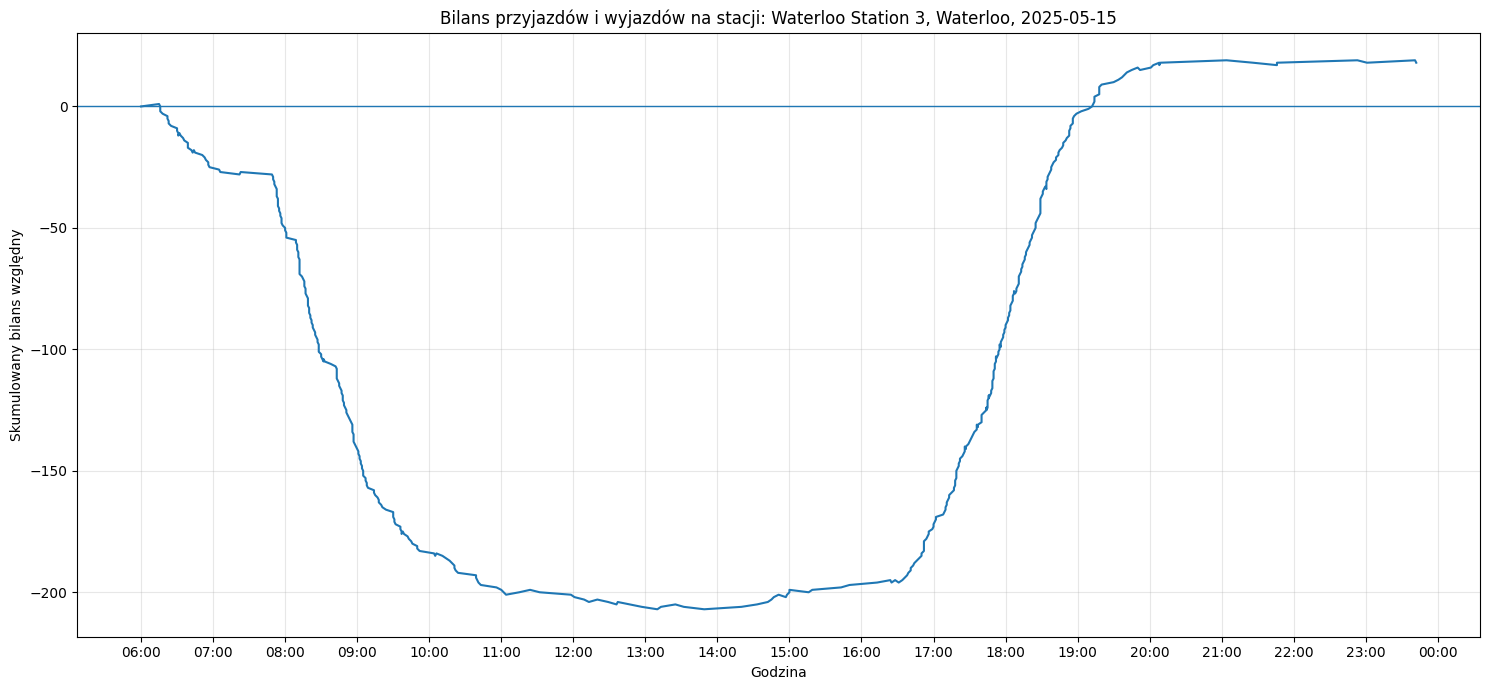

In [ ]:
plt.figure(figsize=(15, 7))

plt.plot(one_day_events["date"], one_day_events["balance"], linewidth=1.5)
plt.axhline(0, linewidth=1)

plt.xlabel("Godzina")
plt.ylabel("Skumulowany bilans względny")
plt.title(f"Bilans przyjazdów i wyjazdów na stacji: {station_name}, {selected_day}")

# ładne godziny na osi X
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=1))

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()